# Mini-Projeto Avaliativo — Análise Exploratória de Dados (Base Varejo)

**Disciplina:** Análise de Dados com Python
**Turma:** Analise_de_Dados_T6
**Autor:** _Julcemar Justino FeLipe_

# Importação das Bibliotecas

## O que será realizado neste notebook

Vamos praticar um fluxo completo de **Análise Exploratória de Dados (AED)**
sobre uma base de compras de varejo, passando por 7 etapas:

1. Carregamento e inspeção inicial da base
2. Diagnóstico de qualidade dos dados (nulos, duplicatas, inconsistências)
3. Limpeza de dados necessária
4. Validação da regra de negócio do identificador de compra (`CO_ID`)
5. Estatísticas descritivas do número de filhos do cliente
6. Padrões de agrupamento
7. Conclusões (insights)

Cada etapa tem uma célula de texto explicando **o que** seráa feito e **por
que**, seguida da célula de código que faz aquilo de fato. Isso ajuda tanto
a entender o raciocínio quanto a rodar o notebook célula por célula no Colab
ou no VSCode.


## Preparação

Importação do `pandas`,`numpy`eo `matplotlib` para gerar os gráficos das análises. Também ajustamos algumas opções de exibição só para o notebook mostrar as tabelas de forma mais legível (todas as colunas, sem cortar linhas).


In [372]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


Ajuste de algumas opções de exibição só para o notebook mostrar as tabelas de forma mais legível (todas as colunas, sem cortar linhas).

In [373]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# *Sprint 1 (Importação e Visualização dos dados)*

## Etapa 1 — Carregamento e inspeção inicial da base

Carregamento do CSV com `pandas.read_csv()`. Duas observações importantes sobre
esse arquivo específico:

- Ele usa **ponto e vírgula (`;`)** como separador de colunas (padrão comum em
  CSVs exportados de planilhas em português) — por isso `sep=";"`.
- O cabeçalho do arquivo original tem um `;` sobrando no final de cada linha.
  Isso faz o pandas criar colunas "fantasmas" (`Unnamed: 10`, `11`, `12`, `13`),
  100% vazias.

Depois, damos uma primeira olhada: quantas linhas e colunas a base tem, quais
são os tipos de dados que o pandas inferiu, e como são as primeiras linhas.

In [374]:
df_inicial = pd.read_csv('Base Varejo.csv',sep=';') # Carregando a base de dados - Base Varejo
print(f'\n{"=" * 50}')
print(f"\nDimensões do dataset: {df_inicial.shape[0]} linhas e {df_inicial.shape[1]} colunas") # exibindo as dimensões do dataset linhas e colunas
print(f'\n{"=" * 50}')
display(df_inicial.head())  # Exibindo as primeiras linhas da base
print(f'\n{"=" * 50}')
print(f'Tipos de dados das colunas:\n{df_inicial.dtypes}')
print(f'\n{"=" * 50}')



Dimensões do dataset: 830000 linhas e 14 colunas



,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN



Tipos de dados das colunas:
DATA               str
CO_ID            int64
CL_ID            int64
CL_GENERO          str
CL_EC            int64
CL_FHL           int64
CL_SEG             str
PR_ID            int64
PR_CAT             str
PR_NOME            str
Unnamed: 10    float64
Unnamed: 11    float64
Unnamed: 12    float64
Unnamed: 13    float64
dtype: object



### Dicionário de dados (colunas do `Base Varejo.csv`)

| Coluna | Significado |
|---|---|
| `DATA` | Data da compra (texto no formato `dd/mm/aaaa`) |
| `CO_ID` | Identificador da **compra** (se repete em cada item da mesma compra) |
| `CL_ID` | Identificador do **cliente** |
| `CL_GENERO` | Gênero do cliente (`M`/`F`) |
| `CL_EC` | Estado civil do cliente (`1 = Casado ou união estável`;` 2 = Divorciado`; `3 = Separado`; `4 = Solteiro`; `5 = Viúvo`) |
| `CL_FHL` | Número de filhos do cliente |
| `CL_SEG` | Segmento do cliente (`A`/`B`/`C`) |
| `PR_ID` | Identificador do **produto** |
| `PR_CAT` | Categoria do produto (pode vir `"#N/D"` quando não informada) |
| `PR_NOME` | Nome do produto |


# Sprint 2  — Diagnóstico de qualidade dos dados

Antes de mexer em qualquer coisa, precisamos **mapear os problemas** da base.
Vamos verificar, um de cada vez:

1. O cabeçalho do arquivo original tem um `;` sobrando no final de cada linha.
  Isso faz o pandas criar colunas "fantasmas" (`Unnamed: 10`, `11`, `12`, `13`),
  100% vazias. Isso já é, por si só, um pequeno problema de qualidade de
  dados — então identificamos e removemos.
2. Valores nulos (`NaN`) por coluna.
3. Categoria ausente representada pela string `"#N/D"` (em vez de um `NaN`
   de verdade — um jeito comum de "esconder" dado faltante como texto).
4. Linhas completamente duplicadas.
5. Datas que não seguem o formato `dd/mm/aaaa`.
6. Inconsistências de texto (ex.: o mesmo produto grafado com maiúsculas e
   minúsculas diferentes, o que faria o pandas tratar como dois produtos
   diferentes num `groupby()`).

### 2.1 — Remoção de colunas vazias

In [375]:
df_inicial = df_inicial.dropna(axis=1, how="all")
print(f'\n{"=" * 50}')
print(f"\nDimensões do dataset após remoção de colunas vazias: {df_inicial.shape[0]} linhas e {df_inicial.shape[1]} colunas")
print(f'\n{"=" * 50}')
display(df_inicial.head())  # Exibindo as primeiras linhas da base



Dimensões do dataset após remoção de colunas vazias: 830000 linhas e 10 colunas



,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


### 2.2 — Valores nulos por coluna

In [376]:
nulos_por_coluna = df_inicial.isnull().sum()
nulos_por_coluna

DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

### 2.3 — Categoria ausente (`"#N/D"`)
Repare que isso **não aparece** como nulo no passo anterior, porque é uma
string de verdade (`"#N/D"`), não um `NaN`. Esse é exatamente o tipo de
problema que só aparece quando você olha os *valores* de uma coluna
categórica, não só a contagem de nulos.

In [377]:
qtd_categoria_nd = (df_inicial["PR_CAT"] == "#N/D").sum()
produtos_sem_categoria = [int(p) for p in df_inicial.loc[df_inicial["PR_CAT"] == "#N/D", "PR_ID"].unique()]
print(f'\n{"=" * 50}')
print(f'\nRegistros com categoria ausente ("#N/D"): {qtd_categoria_nd}')
print(f'\n{"=" * 50}')
print(f'\nProduto(s) (PR_ID) que geram essas ocorrências: {produtos_sem_categoria}')
print(f'\n{"=" * 50}')



Registros com categoria ausente ("#N/D"): 3650


Produto(s) (PR_ID) que geram essas ocorrências: [107]



### 2.4 — Linhas duplicadas

Contamos quantas linhas são **idênticas em todas as colunas** a alguma outra
linha da base. Vamos decidir o que fazer com elas na Etapa 3 — só
diagnosticamos.

In [378]:
qtd_duplicadas_completas = df_inicial.duplicated().sum()
print(f'\n{"=" * 50}')
print(f"\nLinhas 100% duplicadas (todas as colunas iguais): {qtd_duplicadas_completas}")
print(f'\n{"=" * 50}')



Linhas 100% duplicadas (todas as colunas iguais): 96553



### 2.5 — Datas fora do padrão

Converter a coluna `DATA` (texto) para `datetime` usando
`errors="coerce"`: qualquer valor que não siga o formato `dd/mm/aaaa` vira
`NaT` (o "nulo" de datas no pandas), em vez de travar o script com erro.

In [379]:
datas_convertidas_teste = pd.to_datetime(df_inicial["DATA"], format="%d/%m/%Y", errors="coerce")
qtd_datas_invalidas = datas_convertidas_teste.isna().sum()
print(f'\n{"=" * 50}')
print(f'\nDatas que não seguem o formato dd/mm/aaaa (viram NaT): {qtd_datas_invalidas}')
print(f'\n{"=" * 50}')



Datas que não seguem o formato dd/mm/aaaa (viram NaT): 0



### 2.5 — Inconsistência de texto no nome do produto

Procurar nomes de produto que tenham letras minúsculas no meio (a base
está majoritariamente em CAIXA ALTA) 

In [380]:
nomes_com_letras_minusculas_no_meio = df_inicial.loc[
    df_inicial["PR_NOME"].str.contains(r"[a-z]", regex=True, na=False), "PR_NOME"
].unique()

print(f'\n{"=" * 50}')
print(f'\nNomes de produto com inconsistência de maiúsculas/minúsculas: {list(nomes_com_letras_minusculas_no_meio)}')
print(f'\n{"=" * 50}')



Nomes de produto com inconsistência de maiúsculas/minúsculas: ['REFRIGERANTE LIMaO']



## Sprint 3 — Limpeza mínima necessária

Tratamento de cada inconsisitencia — sempre explicando a **decisão** tomada, não só a mecânica do código. Trabalhamos numa cópia (`df`), preservando `df_inicial` intacto para comparação.

In [381]:
df = df_inicial.copy()

### 3.1 — Tratamento da categoria ausente (lógica if/else)

Quando a categoria vem como `"#N/D"`, substituímos por `"Sem Categoria"`.
Optamos por **manter a linha** (não apagar o item): o produto foi de fato
comprado, só a categoria dele não foi cadastrada — apagar a linha jogaria
fora uma venda real. Fazemos o mesmo para o nome do produto (`"#N/D"` vira
`"Produto Nao Informado"`), já que os dois vêm vazios juntos (mesmo
produto, `PR_ID` 107).

In [382]:
def tratar_categoria(categoria: str) -> str:
    if categoria == "#N/D":
        return "Sem Categoria"
    else:
        return categoria


df["PR_CAT"] = df["PR_CAT"].apply(tratar_categoria)
df["PR_NOME"] = df["PR_NOME"].apply(lambda nome: "Produto Nao Informado" if nome == "#N/D" else nome)
print(f'\n{"=" * 50}')
print(f'\nCategoria \"#N/D\" convertida para \"Sem Categoria\" (e nome de produto para \"Produto Nao Informado\").')
print(f'\n{"=" * 50}')



Categoria "#N/D" convertida para "Sem Categoria" (e nome de produto para "Produto Nao Informado").



### 3.2 — Padronização de texto

Convertendo `PR_NOME` e `PR_CAT` para caixa alta, resolvemos de uma vez a
inconsistência encontrada no diagnóstico (`"LIMaO"` vira `"LIMAO"`), evitando
que o mesmo produto seja contado como duas categorias diferentes em um
`groupby()`.

In [383]:
df["PR_NOME"] = df["PR_NOME"].str.upper()
df["PR_CAT"] = df["PR_CAT"].str.upper()

print(f'\n{"=" * 50}')
print(f'\nNomes de produto e categoria padronizados em CAIXA ALTA (corrige ex.: \'LIMaO\' -> \'LIMAO\').')
print(f'\n{"=" * 50}')



Nomes de produto e categoria padronizados em CAIXA ALTA (corrige ex.: 'LIMaO' -> 'LIMAO').



### 3.3 — Conversão de tipos: `DATA` de texto para `datetime`

Já foi confirmado Sprint 2 que não há datas inválidas nesta base , então somente  realizamos a conversão pata `datetime`

In [384]:
df["DATA"] = pd.to_datetime(df["DATA"], format="%d/%m/%Y")
print(f'\n{"=" * 50}')
print(f'\nColuna DATA convertida para datetime. Período coberto: {df["DATA"].min().date()} a {df["DATA"].max().date()}.')
print(f'\n{"=" * 50}')



Coluna DATA convertida para datetime. Período coberto: 2019-01-04 a 2022-12-08.



### 3.4 — Tratamento das linhas duplicadas

Esta é a decisão mais delicada do projeto. A base **não tem uma coluna de
quantidade**. Uma linha duplicada (mesmo `CO_ID` e mesmo `PR_ID`) pode
significar duas coisas:

- **(a)** um erro de lançamento (o item foi registrado duas vezes por
  engano); ou
- **(b)** o cliente realmente levou 2 ou mais unidades do mesmo produto na
  mesma compra (ex.: 2 bananas).

Como não há como diferenciar as duas situações com certeza, e como
simplesmente apagar a linha reduziria a contagem real de itens levados pelo
cliente, optamos por **não descartar a informação**: transformamos a
repetição em uma coluna `QUANTIDADE` explícita. Isso resolve o problema de
duplicatas sem perder informação.

In [385]:
chave_item = ["CO_ID", "PR_ID"]
quantidade_por_item = df.groupby(chave_item).size().rename("QUANTIDADE")
df = df.drop_duplicates(subset=chave_item, keep="first").merge(quantidade_por_item, on=chave_item)
print(f'\n{"=" * 50}')
print(f'\nLinhas após consolidar duplicatas em QUANTIDADE: {df.shape[0]} (eram {df_inicial.shape[0]} linhas brutas).')
print(f'\nTotal de unidades de produto vendidas (soma de QUANTIDADE): {int(df["QUANTIDADE"].sum())}')
print(f'\n{"=" * 50}')



Linhas após consolidar duplicatas em QUANTIDADE: 733447 (eram 830000 linhas brutas).

Total de unidades de produto vendidas (soma de QUANTIDADE): 830000



In [386]:
df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,QUANTIDADE
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,1
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,1
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,1
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,2
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,1


## Sprint 4 — Validação da regra de negócio do `CO_ID`

O enunciado deixa claro que **cada linha da base representa um item
comprado, não uma compra inteira** — o `CO_ID` se repete para todos os itens
de uma mesma compra. Antes de usar essa coluna para agrupar, validamos que
ela realmente se comporta assim: todo `CO_ID` deveria ter sempre o **mesmo**
cliente (mesmo `CL_ID`, gênero, estado civil, filhos, segmento) em todas as
suas linhas.

In [387]:
consistencia_cliente = df.groupby("CO_ID")[["CL_ID", "CL_GENERO", "CL_EC", "CL_FHL", "CL_SEG"]].nunique()
compras_inconsistentes = (consistencia_cliente > 1).any(axis=1).sum()

print(f"Compras (CO_ID) com dados de cliente inconsistentes entre itens: {compras_inconsistentes}")
print("(o esperado é 0 -> confirma que CO_ID realmente identifica UMA compra de UM cliente.)")


Compras (CO_ID) com dados de cliente inconsistentes entre itens: 0
(o esperado é 0 -> confirma que CO_ID realmente identifica UMA compra de UM cliente.)


Confirmada a regra, construímos uma tabela **no nível de compra** (1 linha = 1 compra, não 1 item), agregando os itens por `CO_ID`. Esta é a tabela que vamos usar nas próximas etapas sempre que quisermos falar de "clientes" ou "compras" sem contar o mesmo cliente várias vezes (uma vez por item).

In [388]:
df_compras = df.groupby("CO_ID").agg(
    DATA=("DATA", "first"),
    CL_ID=("CL_ID", "first"),
    CL_GENERO=("CL_GENERO", "first"),
    CL_EC=("CL_EC", "first"),
    CL_FHL=("CL_FHL", "first"),
    CL_SEG=("CL_SEG", "first"),
    QTD_ITENS_DISTINTOS=("PR_ID", "nunique"),
    QTD_UNIDADES=("QUANTIDADE", "sum"),
    QTD_CATEGORIAS_DISTINTAS=("PR_CAT", "nunique"),
).reset_index()

print(f"Número de compras distintas (CO_ID únicos): {df_compras.shape[0]}")
print(f"Número de clientes distintos (CL_ID únicos): {df['CL_ID'].nunique()}")


Número de compras distintas (CO_ID únicos): 18471
Número de clientes distintos (CL_ID únicos): 1000


In [389]:
df_compras.head()

,CO_ID,DATA,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,QTD_ITENS_DISTINTOS,QTD_UNIDADES,QTD_CATEGORIAS_DISTINTAS
0,1000,2019-02-01,534,M,4,1,C,46,52,4
1,1040,2019-02-01,279,M,1,2,B,15,15,5
2,1078,2019-02-01,290,F,1,0,B,63,82,7
3,1082,2019-02-01,323,M,1,3,B,62,71,5
4,1103,2019-02-01,957,M,2,3,B,6,6,3


##  Sprint 5 — Estatísticas descritivas: número de filhos do cliente

Calculamos as estatísticas pedidas (contagem, média, mediana, desvio padrão,
moda, mínimo, máximo e quartis) sobre a coluna `CL_FHL`.

**Detalhe importante:** usamos a tabela `df_compras` (1 linha por compra),
não a tabela de itens. Se calculássemos direto na base de itens, um cliente
que levou 50 itens em uma única compra pesaria 50 vezes mais na estatística
do que um cliente que levou 5 — o que distorceria a média de filhos por
*cliente*.

In [390]:
filhos_por_cliente = (
    df_compras[["CL_ID", "CL_FHL"]]
    .dropna()
    .drop_duplicates("CL_ID")["CL_FHL"]
)
filhos_por_cliente.value_counts().sum()
filhos_por_cliente.describe()


count    1000.00000
mean        1.13600
std         1.41333
min         0.00000
25%         0.00000
50%         0.00000
75%         2.00000
max         4.00000
Name: CL_FHL, dtype: float64

### Gráfico — distribuição do número de filhos por cliente

Como `CL_FHL` só tem 5 valores possíveis (0 a 4), um gráfico de barras com a
contagem de clientes em cada valor.

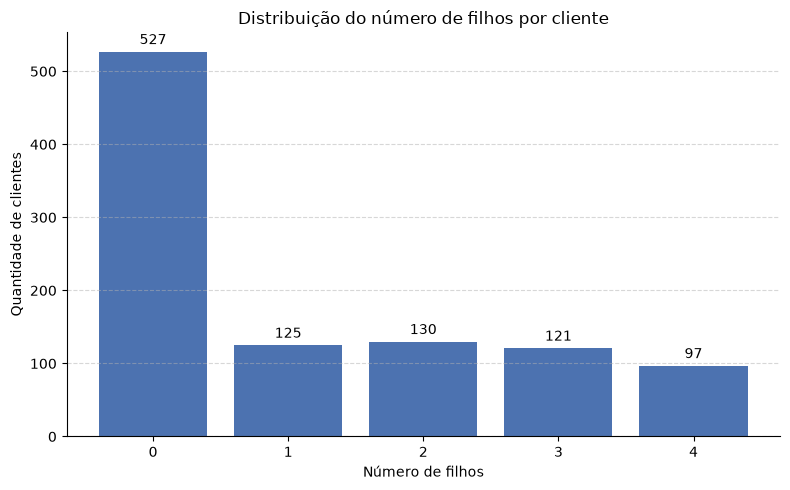

In [391]:

# Distribuição do número de filhos
dist_filhos = (
    filhos_por_cliente
    .value_counts()
    .sort_index()
)

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    dist_filhos.index,
    dist_filhos.values,
    color="#4C72B0"
)

# Exibe os valores sobre as barras
ax.bar_label(barras, padding=3)

# Títulos e rótulos
ax.set_title("Distribuição do número de filhos por cliente")
ax.set_xlabel("Número de filhos")
ax.set_ylabel("Quantidade de clientes")

# Grade
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Sprint 6 — Padrões de agrupamento

O enunciado pede pelo menos **duas combinações** de agrupamento. Fazemos
cinco, para explorar a base sob ângulos diferentes: gênero, categoria,
gênero × categoria (tabela cruzada), segmento × filhos e vendas ao longo do
tempo. Cada tabela vem acompanhada de um gráfico correspondente.

### 6.1 — Itens comprados e compras distintas por gênero

,QTD_ITENS,QTD_UNIDADES,QTD_COMPRAS
CL_GENERO,,,
F,382427,432576,9615
M,351020,397424,8856


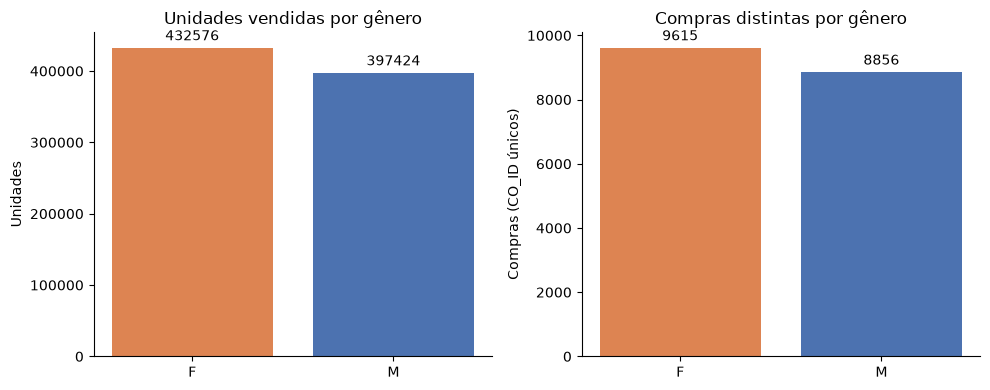

In [392]:
por_genero = df.groupby("CL_GENERO").agg(
    QTD_ITENS=("PR_ID", "count"),
    QTD_UNIDADES=("QUANTIDADE", "sum"),
    QTD_COMPRAS=("CO_ID", "nunique"),
)
display(por_genero.head())


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

barras1 = axes[0].bar(por_genero.index, por_genero["QTD_UNIDADES"], color=["#DD8452", "#4C72B0"])
axes[0].bar_label(barras1, padding=3)
axes[0].set_title("Unidades vendidas por gênero")
axes[0].set_ylabel("Unidades")

barras2 = axes[1].bar(por_genero.index, por_genero["QTD_COMPRAS"], color=["#DD8452", "#4C72B0"])
axes[1].bar_label(barras2, padding=3)
axes[1].set_title("Compras distintas por gênero")
axes[1].set_ylabel("Compras (CO_ID únicos)")

plt.tight_layout()
plt.show()



### 6.2 — Unidades vendidas por categoria de produto (ranking)

,QTD_UNIDADES
PR_CAT,
ALIMENTOS,434767
HIGIENE,155574
LIMPEZA,145754
BEBIDAS,43299
PET,32399


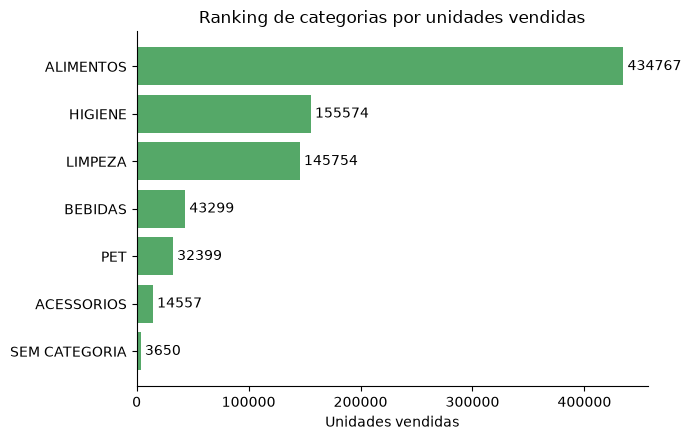

In [393]:
por_categoria = df.groupby("PR_CAT").agg(QTD_UNIDADES=("QUANTIDADE", "sum")).sort_values(
    "QTD_UNIDADES", ascending=False
)
display(por_categoria.head())

fig, ax = plt.subplots(figsize=(7, 4.5))
ordem = por_categoria.sort_values("QTD_UNIDADES")  # crescente, para o maior ficar no topo do barh
barras = ax.barh(ordem.index, ordem["QTD_UNIDADES"], color="#55A868")
ax.bar_label(barras, padding=3)
ax.set_xlabel("Unidades vendidas")
ax.set_title("Ranking de categorias por unidades vendidas")
plt.tight_layout()
plt.show()


### 6.3 — Tabela cruzada gênero × categoria.

PR_CAT,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET,SEM CATEGORIA
CL_GENERO,,,,,,,
F,7700,226575,22345,80991,76298,16749,1918
M,6857,208192,20954,74583,69456,15650,1732


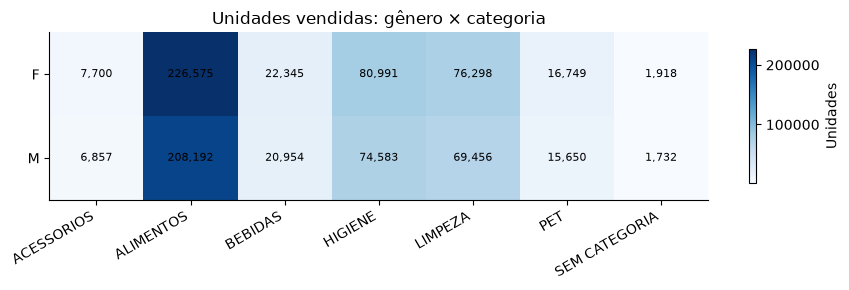

In [394]:
pivot_genero_categoria = df.pivot_table(
    index="CL_GENERO", columns="PR_CAT", values="QUANTIDADE", aggfunc="sum", fill_value=0
)
display(pivot_genero_categoria)

fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(pivot_genero_categoria.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(pivot_genero_categoria.columns)))
ax.set_xticklabels(pivot_genero_categoria.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot_genero_categoria.index)))
ax.set_yticklabels(pivot_genero_categoria.index)

# Escreve o valor de cada célula em cima do quadrado colorido
for i in range(pivot_genero_categoria.shape[0]):
    for j in range(pivot_genero_categoria.shape[1]):
        valor = pivot_genero_categoria.values[i, j]
        ax.text(j, i, f"{valor:,}", ha="center", va="center", fontsize=8)

ax.set_title("Unidades vendidas: gênero × categoria")
fig.colorbar(im, ax=ax, label="Unidades", shrink=0.8)
plt.tight_layout()
plt.show()



### 6.4 — Média de filhos do cliente por segmento (na base de compras)

CL_SEG
C    1.182827
B    1.137465
A    1.052949
Name: CL_FHL, dtype: float64

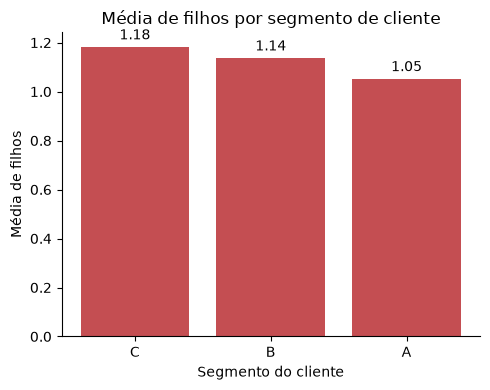

In [395]:
filhos_por_segmento = df_compras.groupby("CL_SEG")["CL_FHL"].mean().sort_values(ascending=False)
display(filhos_por_segmento)
fig, ax = plt.subplots(figsize=(5, 4))
barras = ax.bar(filhos_por_segmento.index, filhos_por_segmento.values, color="#C44E52")
ax.bar_label(barras, fmt="%.2f", padding=3)
ax.set_xlabel("Segmento do cliente")
ax.set_ylabel("Média de filhos")
ax.set_title("Média de filhos por segmento de cliente")
plt.tight_layout()
plt.show()

### 6.5 — Vendas ao longo do tempo

O contexto do desafio pede para entender "como variam as vendas ao longo do
tempo". Agrupamos as unidades vendidas por mês.

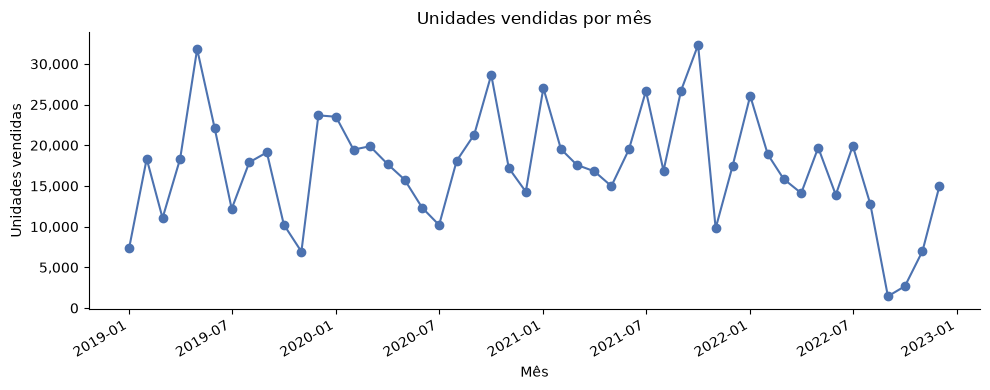

In [396]:
vendas_por_mes = df.groupby(df["DATA"].dt.to_period("M"))["QUANTIDADE"].sum()
vendas_por_mes.index = vendas_por_mes.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(vendas_por_mes.index, vendas_por_mes.values, marker="o", color="#4C72B0")
ax.set_title("Unidades vendidas por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Unidades vendidas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 6.6  — Conclusões (insights)

Por fim, resumimos os principais achados em um bloco de 3 a 6 tópicos,
calculados diretamente a partir dos números das etapas anteriores.

In [397]:
categoria_mais_vendida = por_categoria.index[0]
genero_mais_compras = por_genero["QTD_COMPRAS"].idxmax()
segmento_mais_filhos = filhos_por_segmento.index[0]

conclusoes = [
    f"A base cobre {df_compras.shape[0]} compras de {df['CL_ID'].nunique()} clientes distintos, "
    f"entre {df['DATA'].min().date()} e {df['DATA'].max().date()}.",

    f"A categoria com mais unidades vendidas é '{categoria_mais_vendida}', com "
    f"{int(por_categoria.loc[categoria_mais_vendida, 'QTD_UNIDADES'])} unidades -- bem acima das demais.",

    f"O gênero '{genero_mais_compras}' concentra o maior número de compras "
    f"({int(por_genero.loc[genero_mais_compras, 'QTD_COMPRAS'])} compras), mas a diferença entre "
    f"gêneros é pequena, sem indicar um público dominante.",

    f"O produto de PR_ID={produtos_sem_categoria} responde por 100% dos "
    f"{qtd_categoria_nd} registros com categoria '#N/D': não é um erro aleatório espalhado pela base, "
    f"e sim um único produto que ficou sem cadastro de categoria/nome.",

    f"{qtd_duplicadas_completas} linhas brutas eram duplicatas exatas de item dentro da mesma compra; "
    "em vez de descartadas, foram convertidas em quantidade (coluna QUANTIDADE), preservando a "
    "informação real de quantos itens o cliente levou.",

    f"O número médio de filhos por cliente é {filhos_por_segmento.mean():.2f} (mediana "
    f"{filhos_por_segmento.median():.1f}), e o segmento '{segmento_mais_filhos}' é o que tem, em "
    "média, mais filhos entre os clientes -- pode ser útil para campanhas segmentadas por perfil familiar.",
]

print("Principais insights da análise:\n")
for i, c in enumerate(conclusoes, start=1):
    print(f"{i}. {c}\n")



Principais insights da análise:

1. A base cobre 18471 compras de 1000 clientes distintos, entre 2019-01-04 e 2022-12-08.

2. A categoria com mais unidades vendidas é 'ALIMENTOS', com 434767 unidades -- bem acima das demais.

3. O gênero 'F' concentra o maior número de compras (9615 compras), mas a diferença entre gêneros é pequena, sem indicar um público dominante.

4. O produto de PR_ID=[107] responde por 100% dos 3650 registros com categoria '#N/D': não é um erro aleatório espalhado pela base, e sim um único produto que ficou sem cadastro de categoria/nome.

5. 96553 linhas brutas eram duplicatas exatas de item dentro da mesma compra; em vez de descartadas, foram convertidas em quantidade (coluna QUANTIDADE), preservando a informação real de quantos itens o cliente levou.

6. O número médio de filhos por cliente é 1.12 (mediana 1.1), e o segmento 'C' é o que tem, em média, mais filhos entre os clientes -- pode ser útil para campanhas segmentadas por perfil familiar.



## Salvando a base limpa

Por fim, salvamos os resultados em dois arquivos: `df_limpo.csv` (nível
item, com a coluna `QUANTIDADE`) e `df_compras.csv` (nível compra). Esses são
os arquivos entregáveis pedidos no Sprint 6 do enunciado.

In [398]:
df.to_csv("df_limpo.csv", sep=";", index=False, encoding="utf-8")
df_compras.to_csv("df_compras.csv", sep=";", index=False, encoding="utf-8")

print("Arquivos gerados: df_limpo.csv (nível item) e df_compras.csv (nível compra).")


Arquivos gerados: df_limpo.csv (nível item) e df_compras.csv (nível compra).
